# Day 2 종합실습 — 결혼 경험에 따른 평균 교육연수 비교

- **결혼 경험 있음**: 현재 기혼, 이혼, 별거, 사별
- **결혼 경험 없음**: 미혼
- **귀무가설(H₀)**: 두 집단의 평균 교육연수(`education-num`)는 같다.
- **대립가설(H₁)**: 두 집단의 평균 교육연수는 다르다.
- 유의수준: $\alpha=0.05$, 양측검정

## 프로세스와 구성 이유

1. **환경 설정**: 패키지 버전과 분석 순서를 표시해 재현성을 확보한다.
2. **데이터 품질 점검**: 결측치와 중복을 확인해 분석 표본이 어떻게 만들어졌는지 기록한다.
3. **결혼 경험 집단 정의**: 분류 기준을 코드로 명시하고 원래 혼인 상태별 표본 수도 확인한다.
4. **기술통계와 시각화**: 검정 전에 두 집단의 표본 수, 평균, 분포를 확인한다.
5. **가정 점검**: 분산과 분포를 확인하고, 등분산을 요구하지 않는 Welch t-test 사용 근거를 제시한다.
6. **주 분석—Welch t-test**: 나이와 성별을 보정하지 않은 실제 집단 평균 차이를 검정한다.
7. **보정 분석—회귀분석**: 나이, 나이의 제곱, 성별을 동일하게 고려했을 때의 모델 기반 평균 차이를 추정한다.
8. **강건성 검토**: 부트스트랩과 Mann–Whitney U 검정으로 결론이 특정 검정 가정에만 의존하는지 확인한다.
9. **결론 비교**: 비보정 결과와 보정 결과를 함께 제시하고 통계적 유의성과 효과크기를 구분해 해석한다.
10. **End-to-End 파이프라인**: Pandas·Polars 비교, 결측·중복 처리, Plotly, ML Pipeline, 모델·보고서 저장을 수행한다.

> 이 분석은 집단 간 연관성을 다루며, 결혼 경험이 교육연수를 변화시킨다는 인과관계를 검정하지 않는다.

,도구,버전
0,Python,3.11.15
1,pandas,2.1.4
2,NumPy,1.26.4
3,SciPy,1.11.4
4,Seaborn,0.13.2


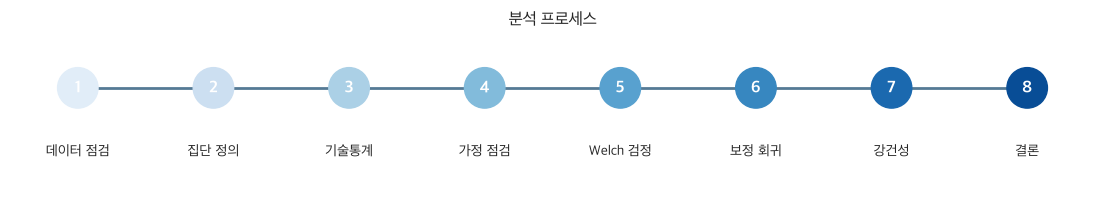

In [1]:
# 1. 환경 설정 — 패키지 버전과 전체 분석 순서를 시각화합니다.
from pathlib import Path
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
import scipy
from scipy import stats
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['axes.unicode_minus'] = False
available_fonts = {item.name for item in font_manager.fontManager.ttflist}
for font in ['Apple SD Gothic Neo', 'Malgun Gothic', 'NanumGothic', 'DejaVu Sans']:
    if font in available_fonts:
        plt.rcParams['font.family'] = font
        break

versions = pd.DataFrame({
    '도구': ['Python', 'pandas', 'NumPy', 'SciPy', 'Seaborn'],
    '버전': [platform.python_version(), pd.__version__, np.__version__, scipy.__version__, sns.__version__]
})
display(versions)

steps = ['데이터 점검', '집단 정의', '기술통계', '가정 점검', 'Welch 검정', '보정 회귀', '강건성', '결론']
fig, ax = plt.subplots(figsize=(14, 2.3))
colors = sns.color_palette('Blues', len(steps))
ax.plot(range(len(steps)), [0] * len(steps), color='#557A95', linewidth=2, zorder=0)
ax.scatter(range(len(steps)), [0] * len(steps), s=850, color=colors, zorder=1)
for i, step in enumerate(steps):
    ax.text(i, 0, str(i + 1), ha='center', va='center', color='white', weight='bold')
    ax.text(i, -0.18, step, ha='center', va='top', fontsize=10)
ax.set(xlim=(-0.5, len(steps)-0.5), ylim=(-0.4, .18), title='분석 프로세스')
ax.axis('off')
plt.show()

,지표,값
0,전체 행,32561
1,전체 열,15
2,완전 중복 행,24
3,education-num 결측,0
4,marital-status 결측,0
5,age 결측,0
6,sex 결측,0


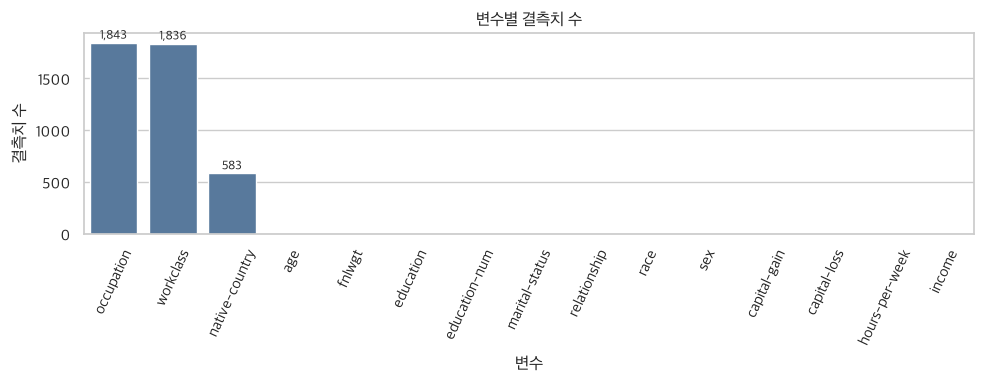

In [2]:
# 2. Adult 데이터 로딩 및 품질 점검
COLUMNS = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]
candidates = [Path('adult.data'), Path.cwd() / 'adult.data', Path.cwd().parent / 'adult.data']
data_path = next((path for path in candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('adult.data를 찾을 수 없습니다. 노트북과 같은 폴더에 두세요.')

raw = pd.read_csv(data_path, header=None, names=COLUMNS, skipinitialspace=True, na_values=['?', ' ?'])
for column in raw.select_dtypes(include=['object', 'string']).columns:
    raw[column] = raw[column].str.strip()
raw['income'] = raw['income'].str.removesuffix('.')

quality = pd.DataFrame({
    '지표': ['전체 행', '전체 열', '완전 중복 행', 'education-num 결측', 'marital-status 결측', 'age 결측', 'sex 결측'],
    '값': [len(raw), raw.shape[1], int(raw.duplicated().sum()), int(raw['education-num'].isna().sum()),
           int(raw['marital-status'].isna().sum()), int(raw['age'].isna().sum()), int(raw['sex'].isna().sum())]
})
display(quality)

missing = raw.isna().sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=missing.index, y=missing.values, color='#4C78A8', ax=ax)
ax.set(title='변수별 결측치 수', xlabel='변수', ylabel='결측치 수')
ax.tick_params(axis='x', rotation=65)
for i, value in enumerate(missing.values):
    if value > 0:
        ax.text(i, value, f'{value:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

,marriage_experience,marital-status,표본수
0,결혼 경험 없음,Never-married,10683
1,결혼 경험 있음,Divorced,4443
2,결혼 경험 있음,Married-AF-spouse,23
3,결혼 경험 있음,Married-civ-spouse,14976
4,결혼 경험 있음,Married-spouse-absent,418
5,결혼 경험 있음,Separated,1025
6,결혼 경험 있음,Widowed,993


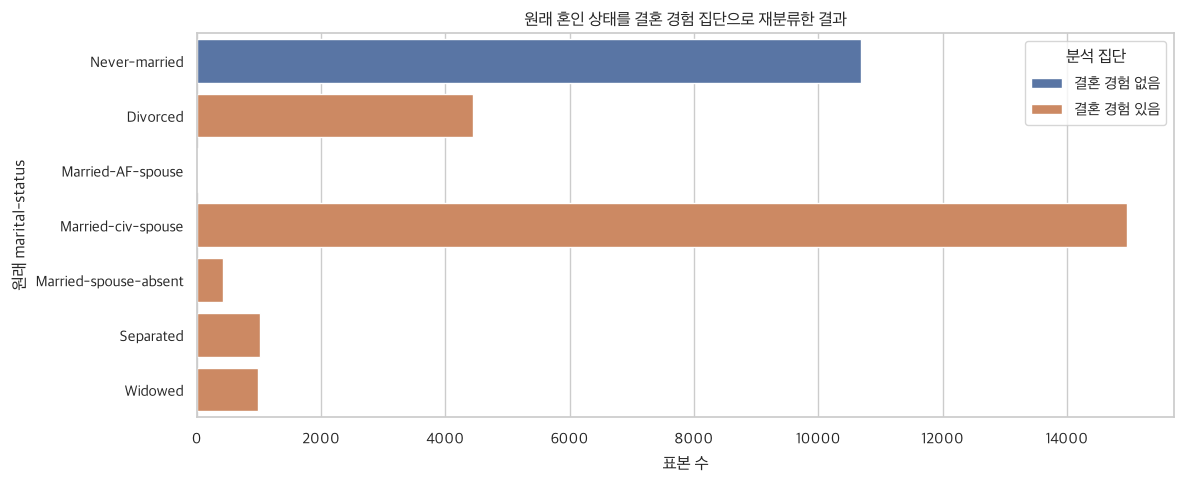

In [3]:
# 3. 결혼 경험 집단 및 연령 범위 정의
# 연령 필터: None은 제한 없음. 예시는 MIN_AGE=30, MAX_AGE=54
MIN_AGE = None
MAX_AGE = None

EVER_MARRIED = {
    'Married-civ-spouse', 'Married-AF-spouse', 'Married-spouse-absent',
    'Divorced', 'Separated', 'Widowed'
}
NEVER_MARRIED = {'Never-married'}
valid_statuses = EVER_MARRIED | NEVER_MARRIED
selected = raw.loc[raw['marital-status'].isin(valid_statuses)].copy()
if MIN_AGE is not None:
    selected = selected.loc[selected['age'] >= MIN_AGE].copy()
if MAX_AGE is not None:
    selected = selected.loc[selected['age'] <= MAX_AGE].copy()

selected['marriage_experience'] = np.where(
    selected['marital-status'].isin(EVER_MARRIED), '결혼 경험 있음', '결혼 경험 없음'
)
selected['marriage_experience'] = pd.Categorical(
    selected['marriage_experience'], categories=['결혼 경험 없음', '결혼 경험 있음'], ordered=True
)
analysis_df = selected.dropna(subset=['education-num', 'age', 'sex', 'marriage_experience']).copy()
analysis_df['ever_married'] = (analysis_df['marriage_experience'] == '결혼 경험 있음').astype(int)

status_summary = (analysis_df.groupby(['marriage_experience', 'marital-status'], observed=True)
                  .size().rename('표본수').reset_index())
display(status_summary)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=status_summary, y='marital-status', x='표본수', hue='marriage_experience', dodge=False, ax=ax)
ax.set(title='원래 혼인 상태를 결혼 경험 집단으로 재분류한 결과', xlabel='표본 수', ylabel='원래 marital-status')
ax.legend(title='분석 집단')
plt.tight_layout()
plt.show()

,marriage_experience,표본수,평균,중앙값,표준편차
0,결혼 경험 없음,"10,683",9.962,10.0,2.388
1,결혼 경험 있음,"21,878",10.138,10.0,2.656


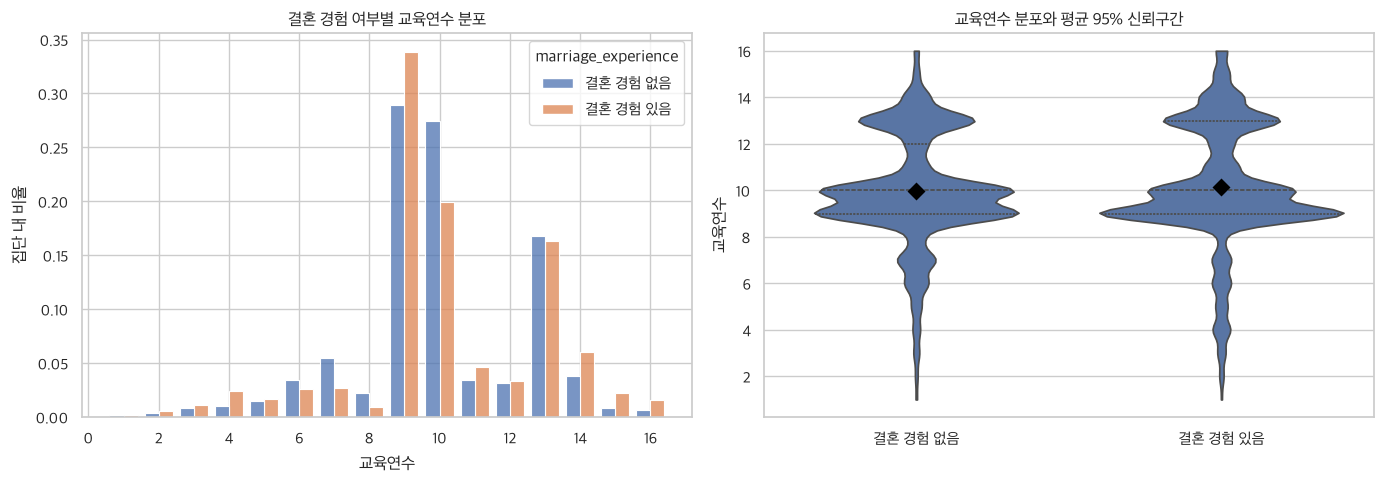

In [4]:
# 4. 집단별 교육연수 기술통계와 분포 확인
sample_summary = (analysis_df.groupby('marriage_experience', observed=False)['education-num']
                  .agg(표본수='size', 평균='mean', 중앙값='median', 표준편차='std')
                  .reset_index())
summary_display = sample_summary.copy()
summary_display['표본수'] = summary_display['표본수'].map(lambda x: f'{x:,.0f}')
for column, digits in [('평균', 3), ('중앙값', 1), ('표준편차', 3)]:
    summary_display[column] = summary_display[column].map(lambda x, d=digits: f'{x:.{d}f}')
display(summary_display)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=analysis_df, x='education-num', hue='marriage_experience', discrete=True,
             stat='probability', common_norm=False, multiple='dodge', shrink=.8, ax=axes[0])
axes[0].set(title='결혼 경험 여부별 교육연수 분포', xlabel='교육연수', ylabel='집단 내 비율')
sns.violinplot(data=analysis_df, x='marriage_experience', y='education-num', inner='quartile', cut=0, ax=axes[1])
sns.pointplot(data=analysis_df, x='marriage_experience', y='education-num', color='black',
              markers='D', linestyles='none', errorbar=('ci', 95), ax=axes[1])
axes[1].set(title='교육연수 분포와 평균 95% 신뢰구간', xlabel='', ylabel='교육연수')
plt.tight_layout()
plt.show()

,점검,값
0,결혼 경험 있음 표본 수,"21,878"
1,결혼 경험 없음 표본 수,"10,683"
2,결혼 경험 있음 분산,7.0564
3,결혼 경험 없음 분산,5.70267
4,Levene 통계량,136.759
5,Levene p-value,1.57438e-31


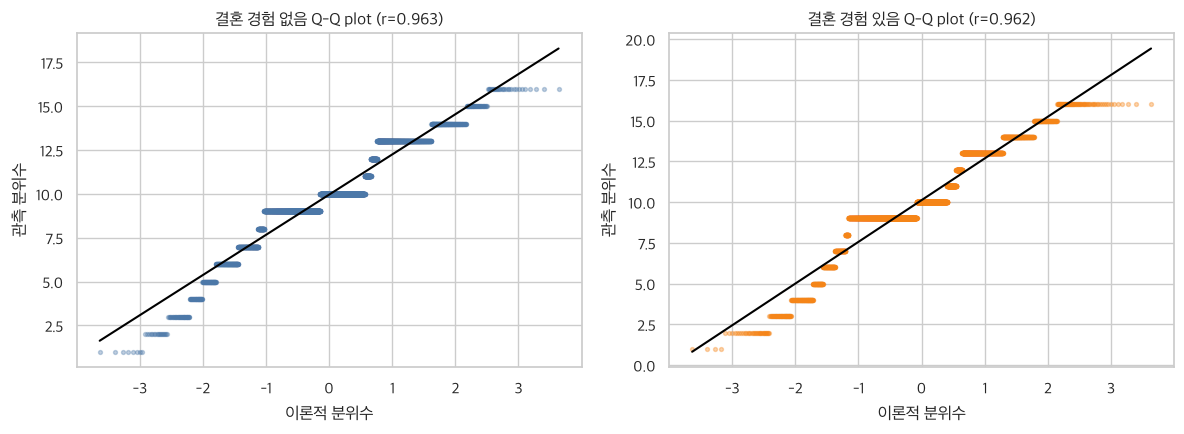

,가정/점검,확인 결과,영향
0,관측 독립성,개인 ID가 없어 직접 검증 불가; Census 행을 서로 다른 응답자로 가정,중복 24행은 동일인인지 판별할 수 없어 제한으로 기록
1,결과변수 범위,education-num 1~16,유효 코드 범위; 평균·효과크기 해석 가능
2,표본 크기,"결혼 경험 있음 21,878, 없음 10,683",비정규·이산 분포에 대한 평균 검정의 근사 안정성 확보
3,등분산,Levene p=1.574e-31; 분산 차이 존재,Student 등분산 t-test보다 Welch가 적절
4,검정 선택,Levene 결과와 무관하게 Welch를 주 분석으로 사전 지정,분산 사전검정에 따른 검정 선택 편향 방지


In [5]:
# 5. 가정 점검 — 분산 사전검정에 의존하지 않고 Welch 검정을 주 분석으로 사용합니다.
never = analysis_df.loc[analysis_df['ever_married'] == 0, 'education-num'].astype(float).to_numpy()
ever = analysis_df.loc[analysis_df['ever_married'] == 1, 'education-num'].astype(float).to_numpy()
levene_stat, levene_p = stats.levene(ever, never, center='median')
assumptions = pd.DataFrame({
    '점검': ['결혼 경험 있음 표본 수', '결혼 경험 없음 표본 수', '결혼 경험 있음 분산',
           '결혼 경험 없음 분산', 'Levene 통계량', 'Levene p-value'],
    '값': [len(ever), len(never), ever.var(ddof=1), never.var(ddof=1), levene_stat, levene_p]
})
assumptions_display = assumptions.copy()
assumptions_display['값'] = assumptions_display['값'].map(lambda x: f'{x:,.6g}')
display(assumptions_display)

rng = np.random.default_rng(42)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for values, title, ax, color in [
    (never, '결혼 경험 없음 Q-Q plot', axes[0], '#4C78A8'),
    (ever, '결혼 경험 있음 Q-Q plot', axes[1], '#F58518')
]:
    sample = rng.choice(values, size=min(5000, len(values)), replace=False)
    (osm, osr), (slope, intercept, r) = stats.probplot(sample, dist='norm')
    ax.scatter(osm, osr, s=8, alpha=.35, color=color)
    ax.plot(osm, slope*np.asarray(osm)+intercept, color='black', linewidth=1.5)
    ax.set(title=f'{title} (r={r:.3f})', xlabel='이론적 분위수', ylabel='관측 분위수')
plt.tight_layout()
plt.show()
# VALIDATION NOTES
# education-num은 1~16의 이산값이라 정규분포와 완전히 같지 않지만,
# 두 집단 표본이 모두 1만 이상이므로 평균의 표본분포에는 중심극한정리를 적용할 수 있습니다.
# Welch 검정은 등분산 여부에 따른 사후 선택이 아니라, 표본 수와 분산이 다른 두 집단에
# 기본적으로 안전한 평균 비교 방법으로 사전에 사용합니다.
assumption_judgement = pd.DataFrame({
    '가정/점검': ['관측 독립성', '결과변수 범위', '표본 크기', '등분산', '검정 선택'],
    '확인 결과': [
        '개인 ID가 없어 직접 검증 불가; Census 행을 서로 다른 응답자로 가정',
        f"education-num {analysis_df['education-num'].min()}~{analysis_df['education-num'].max()}",
        f'결혼 경험 있음 {len(ever):,}, 없음 {len(never):,}',
        f'Levene p={levene_p:.3e}; 분산 차이 존재',
        'Levene 결과와 무관하게 Welch를 주 분석으로 사전 지정',
    ],
    '영향': [
        '중복 24행은 동일인인지 판별할 수 없어 제한으로 기록',
        '유효 코드 범위; 평균·효과크기 해석 가능',
        '비정규·이산 분포에 대한 평균 검정의 근사 안정성 확보',
        'Student 등분산 t-test보다 Welch가 적절',
        '분산 사전검정에 따른 검정 선택 편향 방지',
    ],
})
display(assumption_judgement)


,결혼 경험 있음 평균,결혼 경험 없음 평균,평균 차이(있음-없음),95% CI 하한,95% CI 상한,Welch t,자유도,p-value,Hedges g,판정
0,10.1384,9.96246,0.17594,0.118582,0.233298,6.01231,23331.2,1.85618e-09,0.0684195,귀무가설 기각


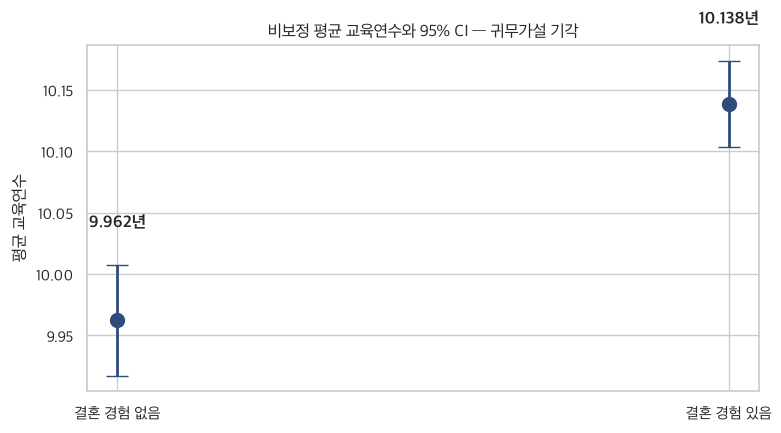

In [6]:
# 6. 주 분석: 양측 Welch 독립표본 t-test
ALPHA = 0.05
t_stat, p_value = stats.ttest_ind(ever, never, equal_var=False, alternative='two-sided')
raw_diff = ever.mean() - never.mean()
var_e, var_n = ever.var(ddof=1), never.var(ddof=1)
raw_se = np.sqrt(var_e/len(ever) + var_n/len(never))
welch_df = (var_e/len(ever) + var_n/len(never))**2 / (
    (var_e/len(ever))**2/(len(ever)-1) + (var_n/len(never))**2/(len(never)-1)
)
critical = stats.t.ppf(1-ALPHA/2, df=welch_df)
raw_ci_low, raw_ci_high = raw_diff-critical*raw_se, raw_diff+critical*raw_se
pooled_sd = np.sqrt(((len(ever)-1)*var_e + (len(never)-1)*var_n)/(len(ever)+len(never)-2))
hedges_correction = 1 - 3/(4*(len(ever)+len(never))-9)
hedges_g = hedges_correction * raw_diff/pooled_sd
welch_decision = '귀무가설 기각' if p_value < ALPHA else '귀무가설 기각 못함'

welch_result = pd.DataFrame({
    '결혼 경험 있음 평균': [ever.mean()], '결혼 경험 없음 평균': [never.mean()],
    '평균 차이(있음-없음)': [raw_diff], '95% CI 하한': [raw_ci_low], '95% CI 상한': [raw_ci_high],
    'Welch t': [t_stat], '자유도': [welch_df], 'p-value': [p_value],
    'Hedges g': [hedges_g], '판정': [welch_decision]
})
welch_display = welch_result.copy()
for column in welch_display.columns:
    if column != '판정':
        welch_display[column] = welch_display[column].map(lambda x: f'{x:.6g}')
display(welch_display)

means = np.array([never.mean(), ever.mean()])
mean_ci = stats.norm.ppf(.975) * np.array([never.std(ddof=1)/np.sqrt(len(never)), ever.std(ddof=1)/np.sqrt(len(ever))])
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(['결혼 경험 없음', '결혼 경험 있음'], means, yerr=mean_ci, fmt='o',
            markersize=10, capsize=8, linewidth=2, color='#2F4B7C')
for x_pos, mean, margin in zip(range(2), means, mean_ci):
    ax.text(x_pos, mean+margin+.03, f'{mean:.3f}년', ha='center', weight='bold')
ax.set(title=f'비보정 평균 교육연수와 95% CI — {welch_decision}', xlabel='', ylabel='평균 교육연수')
plt.tight_layout()
plt.show()

,marriage_experience,표본수,평균나이,나이표준편차,평균교육연수,남성비율
0,결혼 경험 없음,10683,28.1510,10.0072,9.9625,0.5538
1,결혼 경험 있음,21878,43.6749,12.2045,10.1384,0.7256


,검증,추정/통계량,95% CI 또는 자유도,p-value,판단
0,기본 OLS의 일정한 결혼경험 계수,-0.364257,"[-0.439, -0.289]",2.177e-21,참고용: 연령별 차이 일정 가정
1,결혼경험×연령 상호작용 공동검정,59.931386,chi-square df=2,9.684e-14,상호작용 존재—일정 효과 가정 부적절
2,상호작용 허용 후 평균 표준화 차이,-0.391450,"[-0.486, -0.297]",5.845e-16,모델 기반 보정 연관성


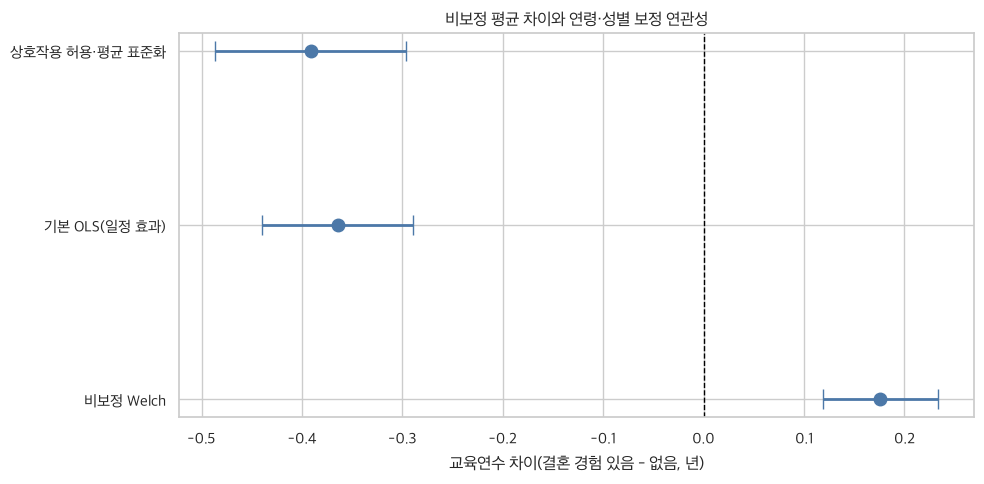

In [7]:
# 7. 보정 분석 검증: 기본 OLS와 연령 상호작용 허용 모델(HC3 강건 표준오차)
# 비보정 평균 차이의 부호가 보정 후 바뀌므로, '결혼 경험 효과가 모든 연령에서 일정하다'는
# 기본 OLS 가정을 결혼 경험×나이, 결혼 경험×나이² 공동 검정으로 확인합니다.
y = analysis_df['education-num'].to_numpy(dtype=float)
age = analysis_df['age'].to_numpy(dtype=float)
age_z = (age-age.mean())/age.std(ddof=0)
male = analysis_df['sex'].eq('Male').to_numpy(dtype=float)
group = analysis_df['ever_married'].to_numpy(dtype=float)

def fit_ols_hc3(design, outcome, terms):
    beta = np.linalg.lstsq(design, outcome, rcond=None)[0]
    residual = outcome-design@beta
    xtx_inv = np.linalg.pinv(design.T@design)
    leverage = np.sum((design@xtx_inv)*design, axis=1)
    hc3_weight = (residual/np.clip(1-leverage, 1e-8, None))**2
    covariance = xtx_inv @ (design.T @ (hc3_weight[:, None]*design)) @ xtx_inv
    standard_error = np.sqrt(np.diag(covariance))
    statistic = beta/standard_error
    p_values = 2*stats.norm.sf(np.abs(statistic))
    ci_low = beta-stats.norm.ppf(.975)*standard_error
    ci_high = beta+stats.norm.ppf(.975)*standard_error
    result = pd.DataFrame({
        '변수': terms, '계수': beta, 'HC3 표준오차': standard_error,
        'z': statistic, 'p-value': p_values,
        '95% CI 하한': ci_low, '95% CI 상한': ci_high,
    })
    return beta, covariance, result

# 참고용 기본 모델: 결혼 경험의 보정 차이가 연령에 관계없이 일정하다고 가정
X_base = np.column_stack([np.ones(len(y)), group, age_z, age_z**2, male])
base_terms = ['절편', '결혼 경험 있음', '나이(표준화)', '나이 제곱', '남성']
base_beta, base_cov, base_result = fit_ols_hc3(X_base, y, base_terms)
base_adjusted_diff = float(base_beta[1])
base_adjusted_se = float(np.sqrt(base_cov[1, 1]))
base_adjusted_ci = (
    base_adjusted_diff-stats.norm.ppf(.975)*base_adjusted_se,
    base_adjusted_diff+stats.norm.ppf(.975)*base_adjusted_se,
)

# 검증 모델: 결혼 경험과 연령의 선형·비선형 상호작용 허용
X_interaction = np.column_stack([
    np.ones(len(y)), group, age_z, age_z**2, male,
    group*age_z, group*(age_z**2),
])
interaction_terms = [
    '절편', '결혼 경험 있음', '나이(표준화)', '나이 제곱', '남성',
    '결혼 경험×나이', '결혼 경험×나이 제곱',
]
interaction_beta, interaction_cov, interaction_result = fit_ols_hc3(
    X_interaction, y, interaction_terms
)

# 두 상호작용 계수의 공동 Wald 검정
interaction_indices = [5, 6]
interaction_vector = interaction_beta[interaction_indices]
interaction_covariance = interaction_cov[np.ix_(interaction_indices, interaction_indices)]
interaction_wald = float(
    interaction_vector @ np.linalg.pinv(interaction_covariance) @ interaction_vector
)
interaction_p = float(stats.chi2.sf(interaction_wald, df=2))

# 같은 관측자의 나이·성별을 유지하고 결혼 경험만 0/1로 바꾸는 평균 표준화
# 상호작용 모델에서 평균 차이의 contrast는 group + mean(age_z)*group:age
# + mean(age_z²)*group:age²입니다.
contrast = np.array([0, 1, 0, 0, 0, age_z.mean(), (age_z**2).mean()])
adjusted_diff = float(contrast@interaction_beta)
adjusted_se = float(np.sqrt(contrast@interaction_cov@contrast))
adjusted_ci_low = adjusted_diff-stats.norm.ppf(.975)*adjusted_se
adjusted_ci_high = adjusted_diff+stats.norm.ppf(.975)*adjusted_se
adjusted_p = float(2*stats.norm.sf(abs(adjusted_diff/adjusted_se)))
adjusted_decision = '0과 다름' if adjusted_p < ALPHA else '0과 다르다고 보기 어려움'

X_never, X_ever = X_interaction.copy(), X_interaction.copy()
X_never[:, [1, 5, 6]] = 0
X_ever[:, 1] = 1
X_ever[:, 5] = age_z
X_ever[:, 6] = age_z**2
adjusted_mean_never = float((X_never@interaction_beta).mean())
adjusted_mean_ever = float((X_ever@interaction_beta).mean())

age_balance = analysis_df.groupby('marriage_experience', observed=False).agg(
    표본수=('age', 'size'), 평균나이=('age', 'mean'), 나이표준편차=('age', 'std'),
    평균교육연수=('education-num', 'mean'), 남성비율=('sex', lambda s: s.eq('Male').mean()),
).reset_index()
display(age_balance.round(4))

interaction_check = pd.DataFrame({
    '검증': ['기본 OLS의 일정한 결혼경험 계수', '결혼경험×연령 상호작용 공동검정',
           '상호작용 허용 후 평균 표준화 차이'],
    '추정/통계량': [base_adjusted_diff, interaction_wald, adjusted_diff],
    '95% CI 또는 자유도': [f'[{base_adjusted_ci[0]:.3f}, {base_adjusted_ci[1]:.3f}]',
                         'chi-square df=2',
                         f'[{adjusted_ci_low:.3f}, {adjusted_ci_high:.3f}]'],
    'p-value': [2*stats.norm.sf(abs(base_adjusted_diff/base_adjusted_se)), interaction_p, adjusted_p],
    '판단': ['참고용: 연령별 차이 일정 가정', '상호작용 존재—일정 효과 가정 부적절',
           '모델 기반 보정 연관성'],
})
interaction_check_display = interaction_check.copy()
interaction_check_display['추정/통계량'] = interaction_check_display['추정/통계량'].map(
    lambda value: f'{value:.6f}'
)
interaction_check_display['p-value'] = interaction_check_display['p-value'].map(
    lambda value: f'{value:.3e}'
)
display(interaction_check_display)

comparison = pd.DataFrame({
    '분석': ['비보정 Welch', '기본 OLS(일정 효과)', '상호작용 허용·평균 표준화'],
    '평균 차이': [raw_diff, base_adjusted_diff, adjusted_diff],
    'CI 하한': [raw_ci_low, base_adjusted_ci[0], adjusted_ci_low],
    'CI 상한': [raw_ci_high, base_adjusted_ci[1], adjusted_ci_high],
})
fig, ax = plt.subplots(figsize=(10, 5))
xerr = np.vstack([
    comparison['평균 차이']-comparison['CI 하한'],
    comparison['CI 상한']-comparison['평균 차이'],
])
ax.errorbar(comparison['평균 차이'], comparison['분석'], xerr=xerr, fmt='o',
            markersize=9, capsize=7, linewidth=2, color='#4C78A8')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set(title='비보정 평균 차이와 연령·성별 보정 연관성',
       xlabel='교육연수 차이(결혼 경험 있음 - 없음, 년)', ylabel='')
plt.tight_layout()
plt.show()


,방법,무엇을 검증하나,결과,해석
0,Welch t-test,비보정 평균 차이,p=1.856e-09,귀무가설 기각
1,평균 차이 부트스트랩,비보정 평균 차이 CI,"95% CI [0.118, 0.232]",0 미포함
2,fnlwgt 가중 평균(기술통계),모집단 가중 시 방향 민감도,가중 차이=0.173년,비보정 차이와 같은 방향
3,Mann–Whitney U(분포/순위),평균이 아닌 분포/순위 차이,p=9.170e-07,보조 결과—평균 가설의 대체 검정 아님


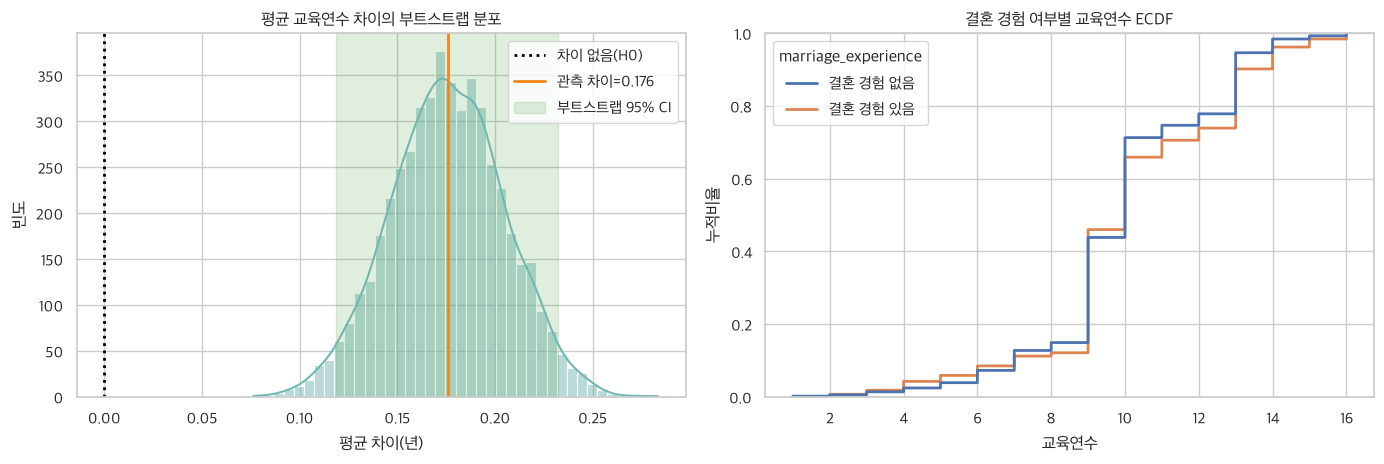

In [8]:
# 8. 강건성 검토: 평균 차이 부트스트랩·가중 기술통계·분포 검정
BOOTSTRAPS = 5000
rng = np.random.default_rng(42)
bootstrap_differences = np.empty(BOOTSTRAPS)
for i in range(BOOTSTRAPS):
    bootstrap_differences[i] = (
        rng.choice(ever, size=len(ever), replace=True).mean()
        - rng.choice(never, size=len(never), replace=True).mean()
    )
boot_low, boot_high = np.quantile(bootstrap_differences, [.025, .975])

# Mann–Whitney는 평균 동일성 검정이 아니라 분포/순위 차이 검정이므로 보조 진단으로만 사용
u_stat, u_p = stats.mannwhitneyu(ever, never, alternative='two-sided')

# fnlwgt는 Census 표본 가중치다. 설계정보가 없어 설계기반 표준오차는 계산하지 않고,
# 가중 평균 차이가 비보정 표본 차이와 같은 방향인지 기술적 민감도만 확인한다.
never_rows = analysis_df['ever_married'].eq(0)
ever_rows = analysis_df['ever_married'].eq(1)
weighted_never = np.average(
    analysis_df.loc[never_rows, 'education-num'],
    weights=analysis_df.loc[never_rows, 'fnlwgt'],
)
weighted_ever = np.average(
    analysis_df.loc[ever_rows, 'education-num'],
    weights=analysis_df.loc[ever_rows, 'fnlwgt'],
)
weighted_diff = weighted_ever-weighted_never

robustness = pd.DataFrame({
    '방법': ['Welch t-test', '평균 차이 부트스트랩', 'fnlwgt 가중 평균(기술통계)',
           'Mann–Whitney U(분포/순위)'],
    '무엇을 검증하나': ['비보정 평균 차이', '비보정 평균 차이 CI', '모집단 가중 시 방향 민감도',
                  '평균이 아닌 분포/순위 차이'],
    '결과': [f'p={p_value:.3e}', f'95% CI [{boot_low:.3f}, {boot_high:.3f}]',
           f'가중 차이={weighted_diff:.3f}년', f'p={u_p:.3e}'],
    '해석': [welch_decision, '0 미포함' if not boot_low <= 0 <= boot_high else '0 포함',
           '비보정 차이와 같은 방향', '보조 결과—평균 가설의 대체 검정 아님'],
})
display(robustness)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.histplot(bootstrap_differences, bins=40, kde=True, color='#72B7B2', ax=axes[0])
axes[0].axvline(0, color='black', linestyle=':', linewidth=2, label='차이 없음(H0)')
axes[0].axvline(raw_diff, color='#F58518', linewidth=2, label=f'관측 차이={raw_diff:.3f}')
axes[0].axvspan(boot_low, boot_high, color='#54A24B', alpha=.18, label='부트스트랩 95% CI')
axes[0].set(title='평균 교육연수 차이의 부트스트랩 분포', xlabel='평균 차이(년)', ylabel='빈도')
axes[0].legend()
sns.ecdfplot(data=analysis_df, x='education-num', hue='marriage_experience', linewidth=2, ax=axes[1])
axes[1].set(title='결혼 경험 여부별 교육연수 ECDF', xlabel='교육연수', ylabel='누적비율')
plt.tight_layout()
plt.show()


,분석 역할,분석,차이(년),95% CI,p-value,해석
0,주 가설,Welch t-test(비보정 평균),0.1759,"[0.119, 0.233]",1.856e-09,H0 기각; 비보정 차이는 매우 작음
1,보정 민감도(참고),기본 OLS(일정 효과),-0.3643,"[-0.439, -0.289]",2.177e-21,상호작용 검정 때문에 단일 계수 해석 제한
2,보정 민감도(권장),연령 상호작용 허용·평균 표준화,-0.3914,"[-0.486, -0.297]",5.845e-16,연령·성별 보정 후 모델 기반 연관성


,항목,결과,판단
0,주 가설 비보정 차이,0.175940,통계적으로 0과 다르지만 약 0.176년
1,비보정 효과크기,0.068419,매우 작음
2,부트스트랩 CI,"[0.118385, 0.232052]",Welch CI와 일치
3,가중 평균 민감도,0.173414,비보정 결과와 같은 방향
4,연령 상호작용 공동검정,"chi2=59.931386, p=9.684224e-14",일정한 결혼경험 계수 가정 부적절
5,상호작용 허용 보정 차이,"-0.391450, 95% CI [-0.486257, -0.296643]",보정 후 음의 연관성; 인과효과 아님


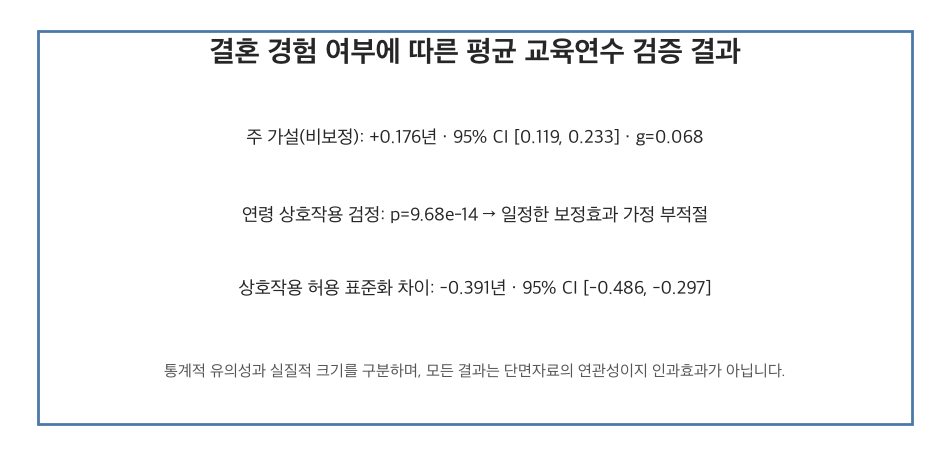

In [9]:
# 9. 검증된 결론 대시보드 — 주 가설과 보정 민감도를 구분합니다.
effect_magnitude = ('매우 작음' if abs(hedges_g) < .2 else '작음' if abs(hedges_g) < .5
                    else '중간' if abs(hedges_g) < .8 else '큼')
final_summary = pd.DataFrame({
    '분석 역할': ['주 가설', '보정 민감도(참고)', '보정 민감도(권장)'],
    '분석': ['Welch t-test(비보정 평균)', '기본 OLS(일정 효과)',
           '연령 상호작용 허용·평균 표준화'],
    '차이(년)': [raw_diff, base_adjusted_diff, adjusted_diff],
    '95% CI': [f'[{raw_ci_low:.3f}, {raw_ci_high:.3f}]',
              f'[{base_adjusted_ci[0]:.3f}, {base_adjusted_ci[1]:.3f}]',
              f'[{adjusted_ci_low:.3f}, {adjusted_ci_high:.3f}]'],
    'p-value': [p_value, 2*stats.norm.sf(abs(base_adjusted_diff/base_adjusted_se)), adjusted_p],
    '해석': ['H0 기각; 비보정 차이는 매우 작음', '상호작용 검정 때문에 단일 계수 해석 제한',
           '연령·성별 보정 후 모델 기반 연관성'],
})
final_display = final_summary.copy()
final_display['차이(년)'] = final_display['차이(년)'].map(lambda value: f'{value:.4f}')
final_display['p-value'] = final_display['p-value'].map(lambda value: f'{value:.3e}')
display(final_display)

validation_summary = pd.DataFrame({
    '항목': ['주 가설 비보정 차이', '비보정 효과크기', '부트스트랩 CI',
           '가중 평균 민감도', '연령 상호작용 공동검정', '상호작용 허용 보정 차이'],
    '결과': [f'{raw_diff:.6f}', f'{hedges_g:.6f}', f'[{boot_low:.6f}, {boot_high:.6f}]',
           f'{weighted_diff:.6f}', f'chi2={interaction_wald:.6f}, p={interaction_p:.6e}',
           f'{adjusted_diff:.6f}, 95% CI [{adjusted_ci_low:.6f}, {adjusted_ci_high:.6f}]'],
    '판단': ['통계적으로 0과 다르지만 약 0.176년', f'{effect_magnitude}', 'Welch CI와 일치',
           '비보정 결과와 같은 방향', '일정한 결혼경험 계수 가정 부적절',
           '보정 후 음의 연관성; 인과효과 아님'],
})
validation_summary.to_csv('artifacts/hypothesis_validation.csv', index=False, encoding='utf-8-sig')
display(validation_summary)

fig, ax = plt.subplots(figsize=(12, 5.6))
ax.axis('off')
ax.text(.5, .88, '결혼 경험 여부에 따른 평균 교육연수 검증 결과',
        ha='center', fontsize=21, weight='bold', transform=ax.transAxes)
ax.text(.5, .69,
        f'주 가설(비보정): +{raw_diff:.3f}년 · 95% CI [{raw_ci_low:.3f}, {raw_ci_high:.3f}] · g={hedges_g:.3f}',
        ha='center', fontsize=13.5, transform=ax.transAxes)
ax.text(.5, .51,
        f'연령 상호작용 검정: p={interaction_p:.2e} → 일정한 보정효과 가정 부적절',
        ha='center', fontsize=13.5, transform=ax.transAxes)
ax.text(.5, .34,
        f'상호작용 허용 표준화 차이: {adjusted_diff:.3f}년 · 95% CI [{adjusted_ci_low:.3f}, {adjusted_ci_high:.3f}]',
        ha='center', fontsize=13.5, transform=ax.transAxes)
ax.text(.5, .15,
        '통계적 유의성과 실질적 크기를 구분하며, 모든 결과는 단면자료의 연관성이지 인과효과가 아닙니다.',
        ha='center', fontsize=11.5, color='#555555', transform=ax.transAxes)
ax.add_patch(plt.Rectangle((.03, .04), .94, .91, fill=False, linewidth=2,
                           edgecolor='#4C78A8', transform=ax.transAxes))
plt.show()


### EDA 이후 검증 결론

- **주 가설:** Welch 검정은 결혼 경험 두 집단의 실제 표본 평균 차이를 검정한다. 차이는 약 `+0.176년`이고 통계적으로 유의하지만 Hedges g가 약 `0.068`이라 실질적 크기는 매우 작다.
- **부호 반전:** 결혼 경험 있음 집단이 평균 약 15.5세 더 나이가 많아 비보정 결과에 연령 구성 차이가 섞여 있다. 연령·성별 보정 후에는 음의 연관성이 나타난다.
- **모델 검증:** 결혼 경험과 연령의 상호작용이 유의하므로, 모든 연령에서 동일한 결혼경험 계수 하나를 해석하지 않는다. 상호작용을 허용한 모델의 평균 표준화 차이를 보정 민감도로 제시한다.
- **강건성:** 평균 차이 부트스트랩과 `fnlwgt` 가중 기술통계는 비보정 차이의 방향을 지지한다. Mann–Whitney U는 평균이 아닌 분포·순위 차이의 보조 결과다.
- **해석 한계:** 주 가설의 H0 기각은 인과효과를 뜻하지 않는다. 보정 결과도 관측된 나이·성별을 통제한 모델 기반 연관성이다.
- **가중치 한계:** `fnlwgt` 가중 평균도 비보정 차이와 같은 방향이지만, 층화·군집·복제 가중치 같은 표본설계 정보가 없어 설계기반 모집단 표준오차와 p-value는 계산하지 않았다.


## 10. 교육연수 가설 기반 모델링

### 모델링 목표

결과변수를 소득이 아니라 연구가설과 동일한 `education-num`으로 둔다.

- **M1 비보정 모델:** `교육연수 ~ 결혼 경험` — 주 가설의 표본 평균 차이를 회귀계수로 표현
- **M2 기본 보정 모델:** `+ 나이 + 나이² + 성별` — 관측된 연령·성별 구성 차이에 대한 민감도
- **M3 상호작용 모델:** `+ 결혼 경험×나이 + 결혼 경험×나이²` — 결혼 경험 차이가 연령에 따라 달라질 수 있도록 허용

OLS를 쓰는 이유는 가설이 평균 교육연수 차이에 관한 것이기 때문이다. `education-num`은 1~16의 이산값이지만 표본이 크고, 추론에는 이분산에 강한 HC3 표준오차를 사용한다. 모델 선택은 예측점수만이 아니라 가설 정합성, 상호작용 검정, 교차검증 오차를 함께 본다.


,모델,평균_RMSE,RMSE_표준편차,평균_MAE,MAE_표준편차,평균_R2,R2_표준편차
0,M1 비보정,2.5715,0.0239,1.9058,0.0195,0.0007,0.0007
1,M2 나이·성별 보정,2.5298,0.0251,1.9160,0.0187,0.0328,0.0057
2,M3 연령 상호작용,2.5276,0.0245,1.9126,0.0181,0.0344,0.0056


M3−M2 평균 RMSE 변화: -0.0022 (M3 우세 22/25 fold)
M3−M2 평균 MAE 변화: -0.0034 (M3 우세 25/25 fold)


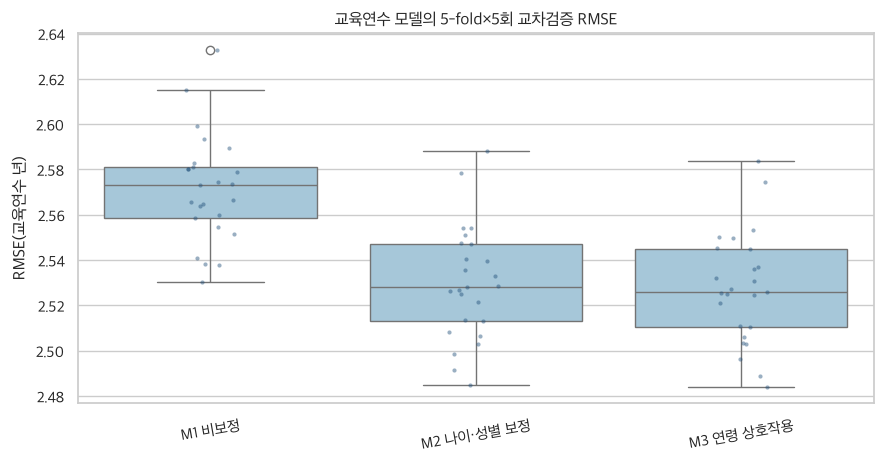

In [10]:
# 10-1. 동일한 5-fold×5회 분할에서 세 교육연수 모델의 일반화 오차 비교
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RepeatedKFold

education_model_df = analysis_df[[
    'education-num', 'ever_married', 'age', 'sex'
]].copy()
education_model_df['male'] = education_model_df['sex'].eq('Male').astype(int)
education_model_df['age_sq'] = education_model_df['age']**2
education_model_df['marriage_age'] = (
    education_model_df['ever_married']*education_model_df['age']
)
education_model_df['marriage_age_sq'] = (
    education_model_df['ever_married']*education_model_df['age_sq']
)

education_model_features = {
    'M1 비보정': ['ever_married'],
    'M2 나이·성별 보정': ['ever_married', 'age', 'age_sq', 'male'],
    'M3 연령 상호작용': [
        'ever_married', 'age', 'age_sq', 'male',
        'marriage_age', 'marriage_age_sq',
    ],
}

splitter = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
cv_rows = []
for split_number, (train_index, test_index) in enumerate(
    splitter.split(education_model_df), start=1
):
    train = education_model_df.iloc[train_index]
    test = education_model_df.iloc[test_index]
    for model_name, feature_names in education_model_features.items():
        model = LinearRegression()
        model.fit(train[feature_names], train['education-num'])
        prediction = model.predict(test[feature_names])
        cv_rows.append({
            '분할': split_number,
            '모델': model_name,
            'RMSE': mean_squared_error(test['education-num'], prediction)**0.5,
            'MAE': mean_absolute_error(test['education-num'], prediction),
            'R2': r2_score(test['education-num'], prediction),
        })

education_model_cv = pd.DataFrame(cv_rows)
education_model_comparison = (
    education_model_cv.groupby('모델', sort=False)
    .agg(
        평균_RMSE=('RMSE', 'mean'), RMSE_표준편차=('RMSE', 'std'),
        평균_MAE=('MAE', 'mean'), MAE_표준편차=('MAE', 'std'),
        평균_R2=('R2', 'mean'), R2_표준편차=('R2', 'std'),
    )
    .reset_index()
)
education_cv_pivot = education_model_cv.pivot(
    index='분할', columns='모델', values=['RMSE', 'MAE', 'R2']
)
m3_vs_m2_rmse = (
    education_cv_pivot[('RMSE', 'M3 연령 상호작용')]
    - education_cv_pivot[('RMSE', 'M2 나이·성별 보정')]
)
m3_vs_m2_mae = (
    education_cv_pivot[('MAE', 'M3 연령 상호작용')]
    - education_cv_pivot[('MAE', 'M2 나이·성별 보정')]
)
display(education_model_comparison.round(4))
print(
    f'M3−M2 평균 RMSE 변화: {m3_vs_m2_rmse.mean():+.4f} '
    f'(M3 우세 {int((m3_vs_m2_rmse < 0).sum())}/25 fold)'
)
print(
    f'M3−M2 평균 MAE 변화: {m3_vs_m2_mae.mean():+.4f} '
    f'(M3 우세 {int((m3_vs_m2_mae < 0).sum())}/25 fold)'
)

education_model_cv.to_csv(
    'artifacts/education_model_cv.csv', index=False, encoding='utf-8-sig'
)
education_model_comparison.to_csv(
    'artifacts/education_model_comparison.csv', index=False, encoding='utf-8-sig'
)

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.boxplot(data=education_model_cv, x='모델', y='RMSE', color='#9ECAE1', ax=ax)
sns.stripplot(data=education_model_cv, x='모델', y='RMSE', color='#1F4E79',
              alpha=.45, size=3, ax=ax)
ax.set(title='교육연수 모델의 5-fold×5회 교차검증 RMSE', xlabel='', ylabel='RMSE(교육연수 년)')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


### 모델 선택 기준

- M1은 연구가설과 직접 일치하지만 연령·성별 구성 차이를 고려하지 않은 주 분석이다.
- M2는 보정 민감도 모델이지만 결혼 경험 차이가 모든 연령에서 일정하다고 가정한다.
- M3는 공동 Wald 검정에서 확인된 연령 상호작용을 반영하며, 교차검증 RMSE도 가장 낮다.
- 다만 R²가 낮다는 것은 교육연수를 잘 예측하는 것이 연구 목적이 아니며, 이 변수들만으로 개인의 교육연수를 설명하기 어렵다는 뜻이다.


In [11]:
# 10-2. 최종 교육연수 모델과 추론 결과 저장
final_education_model = interaction_result.copy()
final_education_model['역할'] = [
    '기준 평균', '기준 연령에서 집단 차이', '미혼 집단 연령 기울기',
    '미혼 집단 연령 곡률', '성별 보정', '집단별 연령 기울기 차이',
    '집단별 연령 곡률 차이',
]
final_education_model.to_csv(
    'artifacts/education_model_final_coefficients.csv',
    index=False,
    encoding='utf-8-sig',
)

model_selection = pd.DataFrame({
    '항목': ['주 가설 모델', '최종 보정 민감도 모델', '상호작용 공동검정',
           '최종 표준화 보정 차이', '해석 범위'],
    '선택/결과': [
        'Welch t-test가 주 검정; M1 비보정 OLS는 같은 평균 차이의 회귀 표현',
        'M3 결혼 경험×나이·나이² 상호작용 OLS(HC3)',
        f'chi-square={interaction_wald:.3f}, p={interaction_p:.3e}',
        f'{adjusted_diff:.3f}년, 95% CI [{adjusted_ci_low:.3f}, {adjusted_ci_high:.3f}]',
        '관측자료의 연관성; 결혼 경험의 인과효과 아님',
    ],
    '이유': [
        '귀무가설이 두 집단 평균의 동일성에 관한 것이기 때문',
        f'연령별 집단 차이가 일정하지 않고, M2 대비 CV RMSE {m3_vs_m2_rmse.mean():+.4f}·MAE {m3_vs_m2_mae.mean():+.4f}',
        'M2의 일정한 결혼경험 계수 가정을 기각',
        '관측된 나이·성별 분포에 평균 표준화한 보정 민감도',
        '무작위 배정이 아니며 미측정 교란 가능성이 존재',
    ],
})
model_selection.to_csv(
    'artifacts/education_model_selection.csv', index=False, encoding='utf-8-sig'
)
display(model_selection)
display(final_education_model.round(6))


,항목,선택/결과,이유
0,주 가설 모델,Welch t-test가 주 검정; M1 비보정 OLS는 같은 평균 차이의 회귀 표현,귀무가설이 두 집단 평균의 동일성에 관한 것이기 때문
1,최종 보정 민감도 모델,M3 결혼 경험×나이·나이² 상호작용 OLS(HC3),"연령별 집단 차이가 일정하지 않고, M2 대비 CV RMSE -0.0022·MAE ..."
2,상호작용 공동검정,"chi-square=59.931, p=9.684e-14",M2의 일정한 결혼경험 계수 가정을 기각
3,최종 표준화 보정 차이,"-0.391년, 95% CI [-0.486, -0.297]",관측된 나이·성별 분포에 평균 표준화한 보정 민감도
4,해석 범위,관측자료의 연관성; 결혼 경험의 인과효과 아님,무작위 배정이 아니며 미측정 교란 가능성이 존재


,변수,계수,HC3 표준오차,z,p-value,95% CI 하한,95% CI 상한,역할
0,절편,10.912511,0.048875,223.274244,0.000000,10.816717,11.008304,기준 평균
1,결혼 경험 있음,-0.587113,0.050598,-11.603496,0.000000,-0.686283,-0.487943,기준 연령에서 집단 차이
2,나이(표준화),0.504472,0.045635,11.054605,0.000000,0.415030,0.593914,미혼 집단 연령 기울기
3,나이 제곱,-0.508272,0.039580,-12.841511,0.000000,-0.585848,-0.430696,미혼 집단 연령 곡률
4,남성,0.011727,0.028972,0.404760,0.685654,-0.045058,0.068511,성별 보정
5,결혼 경험×나이,-0.241119,0.053174,-4.534559,0.000006,-0.345337,-0.136900,집단별 연령 기울기 차이
6,결혼 경험×나이 제곱,0.195663,0.044328,4.413993,0.000010,0.108782,0.282544,집단별 연령 곡률 차이


### 최종 모델링 결론

- **주 가설 결론:** 결혼 경험 있음 집단의 비보정 평균 교육연수는 약 `0.176년` 높지만 효과크기는 매우 작다.
- **최종 보정 모델:** 결혼 경험×연령·나이² 상호작용을 포함한 OLS(HC3)를 사용한다.
- **보정 민감도:** 관측된 나이·성별 분포에 표준화하면 결혼 경험 있음 집단이 약 `0.391년` 낮은 연관성을 보인다.
- **해석:** 비보정과 보정 결과의 부호 차이는 두 집단의 연령 구성이 크게 다르기 때문이다. 어느 결과도 결혼 경험이 교육연수를 변화시킨 인과효과로 해석하지 않는다.
- **예측 한계:** 최종 모델의 교차검증 R²가 낮으므로 개인별 교육연수 예측 모델로 사용하지 않는다.


### 해석 제한

표본이 매우 크면 작은 차이도 통계적으로 유의할 수 있으므로 p-value와 함께 평균 차이, 신뢰구간, 효과크기를 해석한다. 또한 이 분석은 1994년 미국 Adult 데이터의 단면적 연관성이므로 결혼 경험의 인과효과로 표현하지 않는다.